# Advanced Statistics & Outlier Analysis 

This notebook expands basic statistics and outlier detection into a **more advanced analysis** with stunning visualizations.

We use `seaborn`, `matplotlib`, and `scipy` to:

- Explore descriptive statistics (mean, median, mode, std, skewness, kurtosis)
- Detect outliers using multiple methods (Z-score, IQR)
- Visualize data with enhanced boxplots, violin plots, and density curves
- Compare original vs cleaned data side-by-side
- Bootstrap sampling distributions with confidence intervals

## 1. Generate Synthetic Data
We’ll create a **realistic dataset** with a normal distribution and a few added outliers.

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set(style='whitegrid')

np.random.seed(42)
data_normal = np.random.normal(100, 15, 300)
outliers = np.random.normal(160, 5, 5)
data = np.concatenate([data_normal, outliers])
df = pd.DataFrame({'Value': data})

## Descriptive Statistics
We calculate the mean, median, mode, standard deviation, variance, skewness, kurtosis, and the median absolute deviation.

In [9]:
mean = df['Value'].mean()
median = df['Value'].median()
mode = df['Value'].mode()[0]
std = df['Value'].std()
var = df['Value'].var()
skewness = stats.skew(df['Value'])
kurtosis = stats.kurtosis(df['Value'])
mad = stats.median_abs_deviation(df['Value'])

print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Mode: {mode:.2f}")
print(f"Standard Deviation: {std:.2f}")
print(f"Variance: {var:.2f}")
print(f"Skewness: {skewness:.2f}")
print(f"Kurtosis: {kurtosis:.2f}")
print(f"Median Absolute Deviation: {mad:.2f}")

Mean: 100.90
Median: 101.01
Mode: 51.38
Standard Deviation: 16.52
Variance: 272.82
Skewness: 0.74
Kurtosis: 1.97
Median Absolute Deviation: 10.06


## Outlier Detection (Z-score & IQR)
We detect outliers using Z-scores and the IQR method.

In [12]:
z_scores = np.abs(stats.zscore(df['Value']))
df['Outlier_Z'] = z_scores > 3

Q1 = df['Value'].quantile(0.25)
Q3 = df['Value'].quantile(0.75)
IQR = Q3 - Q1
df['Outlier_IQR'] = (df['Value'] < (Q1 - 1.5 * IQR)) | (df['Value'] > (Q3 + 1.5 * IQR))

print(f"Outliers (Z-score method): {df['Outlier_Z'].sum()}")
print(f"Outliers (IQR method): {df['Outlier_IQR'].sum()}")

Outliers (Z-score method): 7
Outliers (IQR method): 8


## Beautiful Visualizations
We draw boxplots, violin plots, and histograms with KDE curves to showcase the data distribution and highlight outliers.

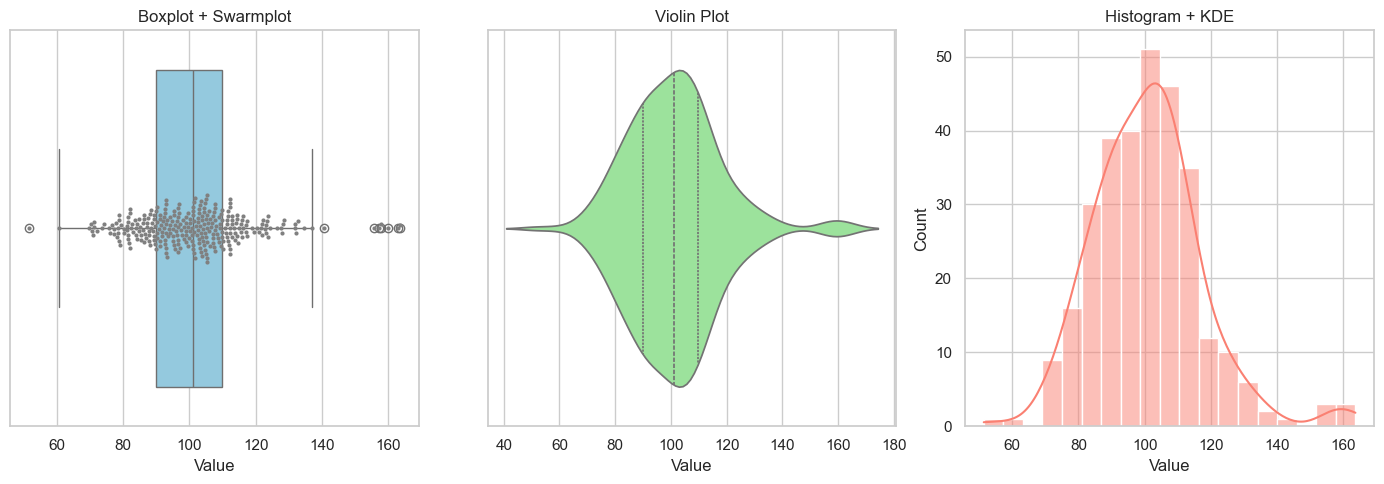

In [18]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1)
sns.boxplot(x=df['Value'], color='skyblue')
sns.swarmplot(x=df['Value'], color='gray', size=3)
plt.title("Boxplot + Swarmplot")

plt.subplot(1, 3, 2)
sns.violinplot(x=df['Value'], inner='quartile', color='lightgreen')
plt.title("Violin Plot")

plt.subplot(1, 3, 3)
sns.histplot(df['Value'], kde=True, color='salmon')
plt.title("Histogram + KDE")

plt.tight_layout()
plt.show()

## Compare Cleaned vs Raw Data
We remove outliers and compare the original vs cleaned data using KDE plots.

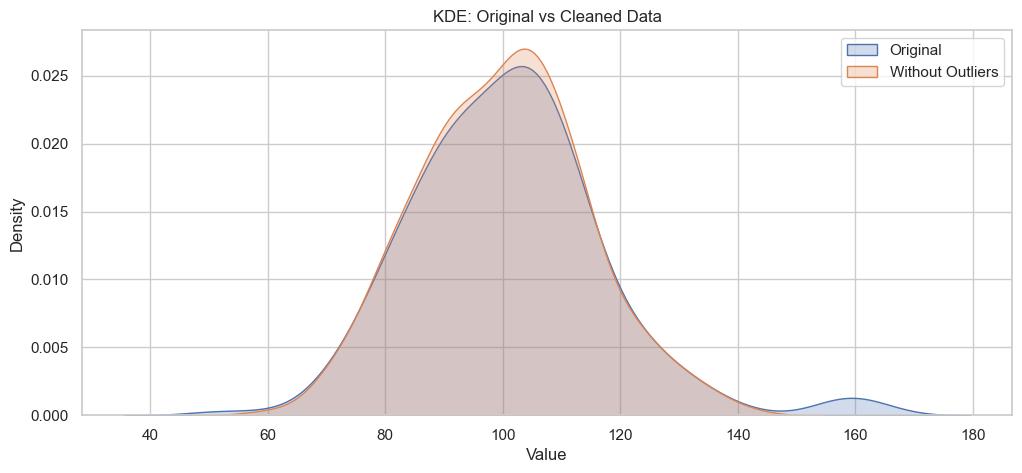

In [21]:
df_clean = df[~df['Outlier_Z']]

plt.figure(figsize=(12,5))
sns.kdeplot(df['Value'], label='Original', fill=True)
sns.kdeplot(df_clean['Value'], label='Without Outliers', fill=True)
plt.legend()
plt.title("KDE: Original vs Cleaned Data")
plt.show()

## Bootstrapping: Confidence Interval for Mean
We bootstrap 1000 samples and visualize the confidence interval.

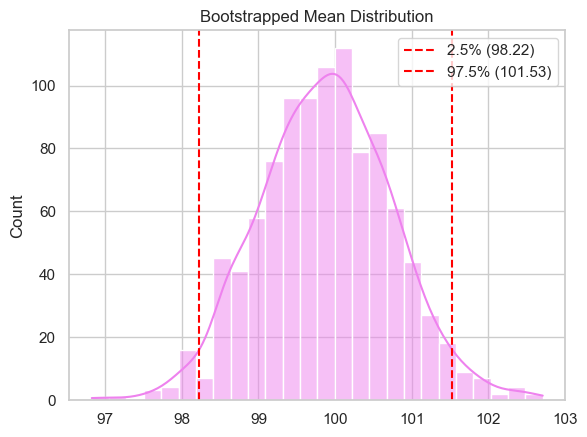

In [24]:
boot_means = [np.mean(np.random.choice(df_clean['Value'], size=len(df_clean), replace=True)) for _ in range(1000)]

ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)

sns.histplot(boot_means, kde=True, color='violet')
plt.axvline(ci_lower, color='red', linestyle='--', label=f'2.5% ({ci_lower:.2f})')
plt.axvline(ci_upper, color='red', linestyle='--', label=f'97.5% ({ci_upper:.2f})')
plt.title("Bootstrapped Mean Distribution")
plt.legend()
plt.show()

## Final Thoughts
We:
- Expanded statistics (mean, mode, skewness, kurtosis)
- Detected outliers with Z-score & IQR
- Beautified visuals (boxplots, violin, KDE)
- Compared raw vs cleaned data
- Bootstrapped confidence intervals

**Better visuals + deeper stats = stronger insights!**